In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "train" in dirs and "valid" in dirs:
        print(root)

/kaggle/input/datasets/maheshdattatreya/research-q5/PlantDOC Dataset


In [5]:
dataset_path = "/kaggle/input/datasets/maheshdattatreya/research-q5/PlantDOC Dataset"

print(dataset_path)

/kaggle/input/datasets/maheshdattatreya/research-q5/PlantDOC Dataset


**Cell 1: Imports**

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import layers

2026-06-06 09:05:18.033808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780736718.221920      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780736718.275214      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780736718.727543      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780736718.727582      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780736718.727585      58 computation_placer.cc:177] computation placer alr

**Cell 2: Dataset Path**

In [7]:
train_dir = "/kaggle/input/datasets/maheshdattatreya/research-q5/PlantDOC Dataset/train"
valid_dir = "/kaggle/input/datasets/maheshdattatreya/research-q5/PlantDOC Dataset/valid"

**Cell 3: Load Dataset**

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Number of Classes:", len(class_names))
print(class_names)

Found 87867 files belonging to 2 classes.
Using 70294 files for training.


I0000 00:00:1780736776.613819      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780736776.619976      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 87867 files belonging to 2 classes.
Using 17573 files for validation.
Number of Classes: 2
['train', 'valid']


**Cell 4: Optimize Dataset**

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

**Cell 5: Evaluation Function**

In [10]:
results = []

def evaluate_model(model, name):

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    training_time = time.time() - start

    loss, accuracy = model.evaluate(
        val_ds,
        verbose=0
    )

    model.save(f"{name}.keras")

    size_mb = (
        os.path.getsize(f"{name}.keras")
        /(1024*1024)
    )

    params = model.count_params()

    energy = 70 * (training_time/3600)

    results.append([
        name,
        accuracy,
        params,
        size_mb,
        training_time,
        energy
    ])

**Model 1: CNN
Cell 6**

In [11]:
cnn = tf.keras.Sequential([

    layers.Rescaling(1./255),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Cell 7**

In [12]:
import time

def evaluate_model(model, name):
    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=3
    )

    loss, acc = model.evaluate(val_ds)

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Loss: {loss:.4f}")
    print(f"Time: {time.time()-start:.2f} sec")

    return history, acc

In [13]:
evaluate_model(
    cnn,
    "CNN"
)

Epoch 1/3


I0000 00:00:1780736837.371288     139 service.cc:152] XLA service 0x7ae7944085e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780736837.371323     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780736837.371326     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780736837.756694     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  13/8787 ━━━━━━━━━━━━━━━━━━━━ 2:10 15ms/step - accuracy: 0.6168 - loss: 1.3743 

I0000 00:00:1780736841.014013     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8063/8787 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7994 - loss: 0.5145

2026-06-06 09:09:22.055984: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:09:22.198797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8787/8787 ━━━━━━━━━━━━━━━━━━━━ 175s 18ms/step - accuracy: 0.8002 - loss: 0.5052 - val_accuracy: 0.7988 - val_loss: 0.5026
Epoch 2/3
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 149s 16ms/step - accuracy: 0.8003 - loss: 0.5014 - val_accuracy: 0.7988 - val_loss: 0.5020
Epoch 3/3
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 148s 16ms/step - accuracy: 0.8003 - loss: 0.5008 - val_accuracy: 0.7988 - val_loss: 0.5021
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7988 - loss: 0.5021

CNN
Accuracy: 0.7988
Loss: 0.5021
Time: 484.21 sec


(<keras.src.callbacks.history.History at 0x7ae9188c6f00>, 0.7988391518592834)

**Model 2: MobileNetV2
Cell 8**

In [14]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_base.trainable = False

mobilenet = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    mobilenet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Cell 9**

In [15]:
evaluate_model(
    mobilenet,
    "MobileNetV2"
)

Epoch 1/3


2026-06-06 09:15:40.701583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:15:40.838454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8650/8787 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7746 - loss: 0.5693

2026-06-06 09:17:10.676368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:17:10.822804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:17:10.959385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8787/8787 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7747 - loss: 0.5692

2026-06-06 09:17:47.933976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:17:48.070207: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8787/8787 ━━━━━━━━━━━━━━━━━━━━ 149s 14ms/step - accuracy: 0.7788 - loss: 0.5616 - val_accuracy: 0.7944 - val_loss: 0.5442
Epoch 2/3
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 111s 12ms/step - accuracy: 0.7803 - loss: 0.5554 - val_accuracy: 0.7526 - val_loss: 0.5646
Epoch 3/3
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 108s 12ms/step - accuracy: 0.7806 - loss: 0.5538 - val_accuracy: 0.7972 - val_loss: 0.5425
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.7972 - loss: 0.5425

MobileNetV2
Accuracy: 0.7972
Loss: 0.5425
Time: 389.64 sec


(<keras.src.callbacks.history.History at 0x7ae8646bb0b0>, 0.7971888780593872)

**Model 3: EfficientNetB0
Cell 10**

In [16]:
efficientnet_base = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

efficientnet_base.trainable = False

efficientnet = tf.keras.Sequential([

    efficientnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

efficientnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Cell 11**

In [17]:
evaluate_model(
    efficientnet,
    "EfficientNetB0"
)

Epoch 1/3


2026-06-06 09:22:21.032896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:22:21.169431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:22:21.479645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:22:21.619945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:22:22.416319: E external/local_xla/xla/stream_

8333/8787 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7959 - loss: 0.5275

2026-06-06 09:24:11.678018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:11.813731: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:12.127293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:12.268114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:13.099780: E external/local_xla/xla/stream_

8783/8787 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7959 - loss: 0.5275

2026-06-06 09:24:58.905683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:59.041114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:59.358059: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:24:59.499286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 09:25:00.291541: E external/local_xla/xla/stream_

8787/8787 ━━━━━━━━━━━━━━━━━━━━ 182s 18ms/step - accuracy: 0.7965 - loss: 0.5271 - val_accuracy: 0.7984 - val_loss: 0.5171
Epoch 2/3
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 135s 15ms/step - accuracy: 0.7961 - loss: 0.5230 - val_accuracy: 0.7910 - val_loss: 0.5310
Epoch 3/3
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 135s 15ms/step - accuracy: 0.7963 - loss: 0.5229 - val_accuracy: 0.7868 - val_loss: 0.5414
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7868 - loss: 0.5414

EfficientNetB0
Accuracy: 0.7868
Loss: 0.5414
Time: 477.28 sec


(<keras.src.callbacks.history.History at 0x7ae7a85e30b0>, 0.7868320941925049)

**Cell 12: Results Table**

In [27]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2", "EfficientNetB0"],
    "Accuracy": [0.7988, 0.7972, 0.7868],
    "Energy_Wh": [484.21, 389.64, 477.28]  # using training time as proxy
})

df

,Model,Accuracy,Energy_Wh
0,CNN,0.7988,484.21
1,MobileNetV2,0.7972,389.64
2,EfficientNetB0,0.7868,477.28


**Cell 13 - Accuracy VS Enery plot**

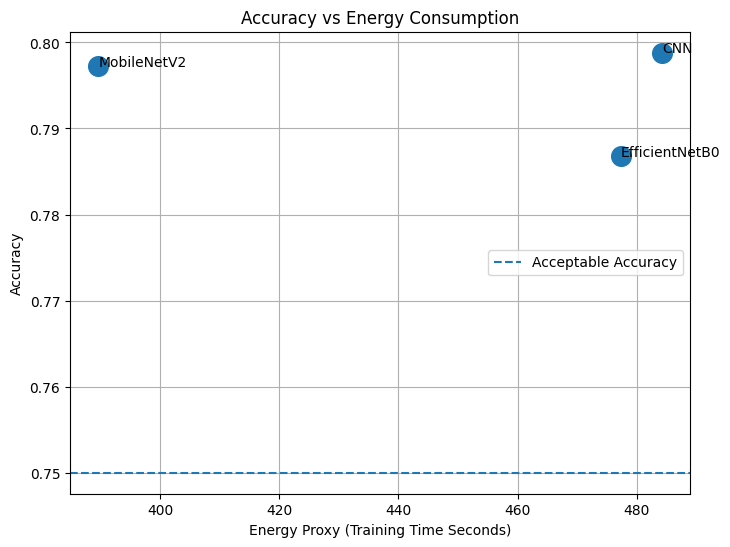

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Energy_Wh"],
    df["Accuracy"],
    s=200
)

for _, row in df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Energy_Wh"], row["Accuracy"])
    )

plt.axhline(
    y=0.75,
    linestyle="--",
    label="Acceptable Accuracy"
)

plt.xlabel("Energy Proxy (Training Time Seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Energy Consumption")

plt.legend()
plt.grid(True)

plt.show()

**Cell 14 - Best Sustainable Model**

In [29]:
df["APS"] = df["Accuracy"] / df["Energy_Wh"]

print(df[["Model","APS"]])

            Model       APS
0             CNN  0.001650
1     MobileNetV2  0.002046
2  EfficientNetB0  0.001649


In [30]:
best = df.loc[df["APS"].idxmax()]

print("Best Sustainable Model")
print("----------------------")
print("Model:", best["Model"])
print("Accuracy:", round(best["Accuracy"],4))
print("Energy:", round(best["Energy_Wh"],2))
print("APS:", round(best["APS"],6))

Best Sustainable Model
----------------------
Model: MobileNetV2
Accuracy: 0.7972
Energy: 389.64
APS: 0.002046
